### Analysis for Exchange Rate (Different shapelets for Error Thresholds)

In [13]:
import math
import os
import tempfile

import pandas as pd
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed
from transformers.integrations import INTEGRATION_TO_CALLBACK
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
import pickle

from tsfm_public import TimeSeriesPreprocessor, TrackingCallback, count_parameters, get_datasets, TinyTimeMixerForPrediction
from tsfm_public.toolkit.get_model import get_model
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.visualization import plot_predictions
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("/Users/shivanitomar/Documents/Implementations/ps_pgsm_shapelets/incremental_code")
import utils

### Helper functions

In [14]:
def z_norm(x):
        return (x - np.mean(x)) / np.std(x)

def shapelet_distance(segment, series):
    seg = z_norm(segment)
    series = z_norm(series)
    seg_len = len(seg)
    return min(np.linalg.norm(seg - series[i:i+seg_len]) for i in range(len(series)-seg_len+1))

def shapelet_distance_w_idx(segment, series):
    seg = z_norm(segment)
    series = z_norm(series)
    seg_len = len(seg)

    min_dist = float('inf')
    min_idx = -1

    # Slide the segment across the series
    for i in range(len(series) - seg_len + 1):
        dist = np.linalg.norm(seg - series[i:i+seg_len])
        if dist < min_dist:
            min_dist = dist
            min_idx = i

    return min_dist, min_idx

def construct_output_df(data, model_trainer):

    preds = model_trainer.predict(data)
    
    output_dict = {
        "date": [],
        "actual": [],
        "pred" : [],
        "context": [],
        "full_window": [],
    }      

    for i in range(len(data)):
        ts = data[i]["timestamp"]
        fv = data[i]["future_values"].numpy().flatten()
        pv = data[i]["past_values"].numpy().flatten()
        w = np.concatenate([pv, fv])

        output_dict["date"].append(ts)
        output_dict["actual"].append(list(fv))
        output_dict["context"].append(list(pv))
        output_dict["full_window"].append(list(w))

    # extracting zero shot predictions on val/test data
    for i in range(len(preds.predictions[0])):
        pred = preds.predictions[0][i].flatten()
        output_dict["pred"].append(list(pred))

    output_df = pd.DataFrame({
        "date": output_dict["date"],
        "prediction": output_dict["pred"],
        "actual": output_dict["actual"],
        "context": output_dict["context"],
        "full_window" : output_dict["full_window"],
    })
    return output_df

In [4]:
# Set seed for reproducibility
# seeds = [88]
seeds = [44, 88, 22]
# SEED = 88, 11

# set_seed(SEED)

TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

CONTEXT_LENGTH = 512
PREDICTION_LENGTH = 96
BATCH_SIZE = 64
timestamp_column = "timestamp"
TARGET_DATASET = "exchange_rate"
dataset_path = "/Users/shivanitomar/Documents/Implementations/SD_forger/FMforTS/data/monash_exchange_rate.csv"


# Results dir
OUT_DIR = "ttm_finetuned_models/"


# columns
id_columns = []
target_columns = ['currency_4']
split_config = {
    "train": 0.7, 
    "test": 0.2
}
data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
    "observable_columns": []
}
tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=CONTEXT_LENGTH,
        prediction_length=PREDICTION_LENGTH,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )
dset_train, dset_valid, dset_test = get_datasets(
        tsp, data, split_config
    )
print("Length of train/val/test", len(dset_train), len(dset_valid), len(dset_test))

Length of train/val/test 4704 665 1422


In [15]:
# Set seed for reproducibility
seeds = [44, 88, 22]
# SEED = 88, 11

# set_seed(SEED)

TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"

CONTEXT_LENGTH = 512
PREDICTION_LENGTH = 96
BATCH_SIZE = 64
timestamp_column = "date"
TARGET_DATASET = "ettm1"
dataset_path = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTm2.csv"


# Results dir
OUT_DIR = "ttm_finetuned_models/"


# columns
id_columns = []
target_columns = ['OT']
# split_config = {
#     "train": [0, 8640],
#     "valid": [8640, 11520],
#     "test": [
#         11520,
#         14400,
#     ],
# }
# split config for ETTm1/m2
split_config = {
    "train": [0, 34560],
    "valid": [34560, 46080],
    "test": [
        46080,
        57600,
    ],
}
data = pd.read_csv(
    dataset_path,
    parse_dates=[timestamp_column],
)

column_specifiers = {
    "timestamp_column": timestamp_column,
    "id_columns": id_columns,
    "target_columns": target_columns,
    "control_columns": [],
    "observable_columns": []
}
tsp = TimeSeriesPreprocessor(
        **column_specifiers,
        context_length=CONTEXT_LENGTH,
        prediction_length=PREDICTION_LENGTH,
        scaling=True,
        encode_categorical=False,
        scaler_type="standard",
    )
dset_train, dset_valid, dset_test = get_datasets(
        tsp, data, split_config
    )
print("Length of the train/val/test splits are as follows : ", len(dset_train), len(dset_valid), len(dset_test))

Length of the train/val/test splits are as follows :  33953 11425 11425


In [16]:
percent = 0.2
drop_limit = int(percent * len(dset_test))

Running the exchange rate shapelet matching analysis...
Error Threshold: mean error + 2 * std deviation
sampe_idx: 195 shapelet_key: shapelet_11
min distance is 4.147866725921631 and matching offset is 127


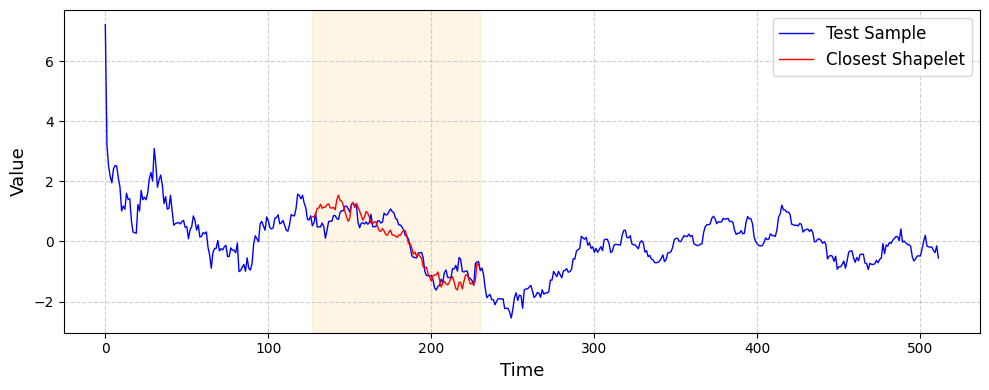

sampe_idx: 217 shapelet_key: shapelet_24
min distance is 4.340219497680664 and matching offset is 115


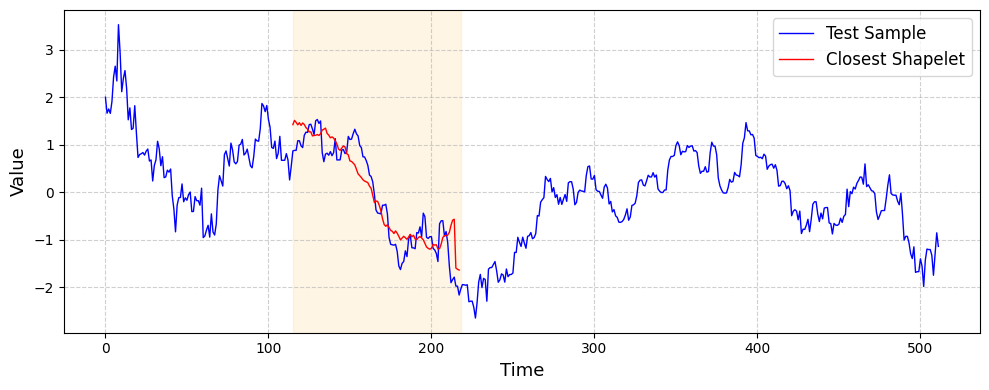

In [ ]:
# Loading the shapelets for exchange rate and comparing the matching test context to add the discussion in the paper (Figure 7 of the draft)

list_of_thresholds = [1]
print("Drop limit is ", drop_limit)
print("List of thresholds to analyze: ", list_of_thresholds)
print("Total test samples: ", len(dset_test))
print("dataset name: ", TARGET_DATASET)

for i in list_of_thresholds:

    file_path = f"/Users/shivanitomar/Documents/Implementations/granite-tsfm/notebooks/AAAI2026/ablations_{i}std/results/exchange_rate/seed_22/topK_shapelets.pkl"
    with open(file_path, 'rb') as handle:
        a_dict = pickle.load(handle)

    print("Running the exchange rate shapelet matching analysis...")  
    print(f"Error Threshold: mean error + {i} * std deviation")

    test_distances_ed = np.zeros((len(dset_test), len(a_dict)))
    for i in range(len(dset_test)):
        for j, (key, value) in enumerate(a_dict.items()):
            # print(key)
            series = np.array(dset_test[i]["past_values"].squeeze(1))
            dist = shapelet_distance(value, series)
            test_distances_ed[i, j] = dist

    shapelet_mapping_df = pd.DataFrame({"key": a_dict.keys(),
                                "shapelet_idx": range(len(a_dict))
                                })

    min_dists = test_distances_ed.min(axis=1)
    shap_indices = np.argmin(test_distances_ed, axis=1)

    mapping_df = pd.DataFrame({"min_distance": min_dists,
                                "shapelet_idx": shap_indices,
                                "sample_idx": range(len(min_dists))
                                })
    
    merged_df = mapping_df.merge(shapelet_mapping_df, on='shapelet_idx', how='left')
    
    sorted_idx = np.argsort(min_dists)
    samples_to_drop = sorted_idx[:drop_limit]

    # sort the mapping df based on min_distances
    sorted_df = merged_df.sort_values(by='min_distance', ascending=True)
    drop_df = sorted_df.head(drop_limit)

    # get the best matching sample for each shapelet from the drop_df and its best match sample
    idx = drop_df.groupby('shapelet_idx')['min_distance'].idxmin()
    best_rows = drop_df.loc[idx].reset_index(drop=True)

    for i in range(len(best_rows)):

        sample_idx = best_rows.iloc[i]['sample_idx']
        shapelet_key = best_rows.iloc[i]['key']
        print("sampe_idx:", sample_idx, "shapelet_key:", shapelet_key)
        # one test sample and its closest shapelet
        sample = np.array(dset_test[sample_idx]["past_values"].squeeze(1))   
        # shap_key = shapelet_mapping_df[shapelet_mapping_df["shapelet_idx"] == 5]['key'].iloc[0] 
        # print("closest matching shapelet key is ", shap_key)
        shapelet = a_dict[shapelet_key]
        min_dist, start_idx = shapelet_distance_w_idx(shapelet, sample)
        print(f"min distance is {min_dist} and matching offset is {start_idx}")
        end_idx = start_idx + len(shapelet)

        sample_scaled = z_norm(sample)
        shapelet_scaled = z_norm(shapelet)
        # Create x-axis for time
        x_sample = np.arange(len(sample))
        x_shapelet = np.arange(start_idx, end_idx)

        # --- Plot ---
        plt.figure(figsize=(10, 4))
        plt.plot(x_sample, sample_scaled, label="Test Sample", color='blue', linewidth=1, alpha=1)
        plt.plot(x_shapelet, shapelet_scaled, label="Closest Shapelet", color='red', linewidth=1)

        # Highlight the matched region
        plt.axvspan(start_idx, end_idx, color='orange', alpha=0.1)

        plt.xlabel("Time", fontsize=13)
        plt.ylabel("Value", fontsize=13)
        # plt.title("Sample and Closest Shapelet (Aligned)", fontsize=15, pad=10)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()





    # # to get the final list of shapelets that matched with top
    # top_matches_set = set(drop_df["closest_shap_idx"]) #get the unique shapelet indices from the topk matches
    # list_of_shapelets = [] #list to store the keys of the top matching shapelets
    # for idx in top_matches_set:
    #     if idx in shapelet_mapping_df["shapelet_idx"].values:
    #         key = shapelet_mapping_df[shapelet_mapping_df["shapelet_idx"] == idx]['key'].iloc[0]
    #         list_of_shapelets.append(key)

    # print("Top matching shapelets keys:", list_of_shapelets)



    
    

    # for shapelet_key in list_of_shapelets:
    #     shapelet = a_dict[shapelet_key]
    #     plt.figure(figsize=(8, 3))
    #     plt.plot(shapelet, color='blue')
    #     plt.title(f"{shapelet_key}")
    #     plt.xlabel("Time")
    #     plt.ylabel("Value")
    #     plt.show()

In [13]:
fft_model = TinyTimeMixerForPrediction.from_pretrained("/Users/shivanitomar/Documents/Implementations/granite-tsfm/notebooks/AAAI2026/ttm_finetuned_models/exchange_rate/v1_fft/checkpoint-2499")
temp_dir = tempfile.mkdtemp()

fft_trainer = Trainer(
        model=fft_model,
        args=TrainingArguments(
            output_dir=temp_dir,
            per_device_eval_batch_size=64,
            seed=88,
            report_to="none",
        ),
    )
fft_test_df = construct_output_df(dset_test, fft_trainer)

/opt/homebrew/Caskroom/miniforge/base/envs/ttm_env_new3.10/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


### Replicating standard scaling 


In [ ]:
# standard scaling uisng train data 
train_len = int(0.7 * len(data))
scaler = StandardScaler()
print(train_len)

X_train_scaled = scaler.fit_transform(data["currency_4"].values[:train_len].reshape(-1, 1))

# Transform val/test using same scaler
X_val_scaled = scaler.transform(data["currency_4"].values[train_len - 512: int(train_len + (0.1 * len(data)))].reshape(-1, 1))
X_test_scaled = scaler.transform(data["currency_4"].values[train_len + int(0.1 * len(data)) - 512:].reshape(-1, 1))

valid_arr = np.zeros((len(dset_valid), CONTEXT_LENGTH + PREDICTION_LENGTH))
for i in range(len(dset_valid)):
    arr = dset_valid[i]["past_values"].numpy().flatten()
    arr = np.concatenate([arr, dset_valid[i]["future_values"].numpy().flatten()])
    valid_arr[i] = arr
